# Generative Adversarial Networks Exploration

Author: Alessio Carnevale

In [20]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow import keras
from keras.datasets import mnist



In [21]:
(x_train, y_train), (_, _) = mnist.load_data()
x_train = (x_train / 255.0).astype(np.float32)
x_train = x_train.reshape(-1, 28, 28, 1) # Reshape for input to CNNs

importing y_train for visualization purposes only. It will not be used in the training of the model

In [15]:
x_train.shape

(60000, 28, 28, 1)

### 10 Random images 

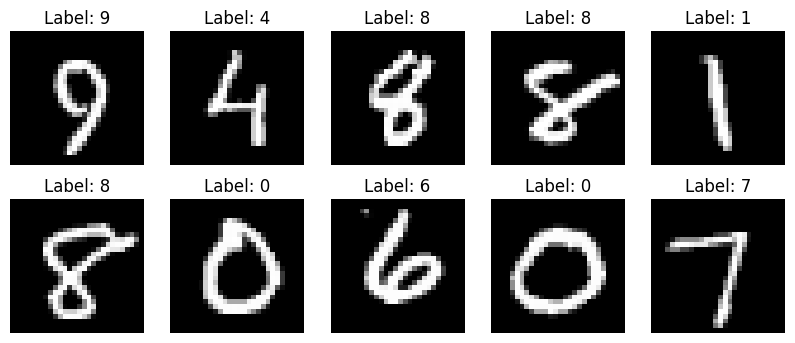

In [16]:
random_indices = np.random.choice(len(x_train), 10, replace=False)
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, idx in enumerate(random_indices):
    axes[i//5, i%5].imshow(x_train[idx].reshape(28, 28), cmap='gray')
    axes[i//5, i%5].set_title(f'Label: {y_train[idx]}')
    axes[i//5, i%5].axis('off')
plt.show()

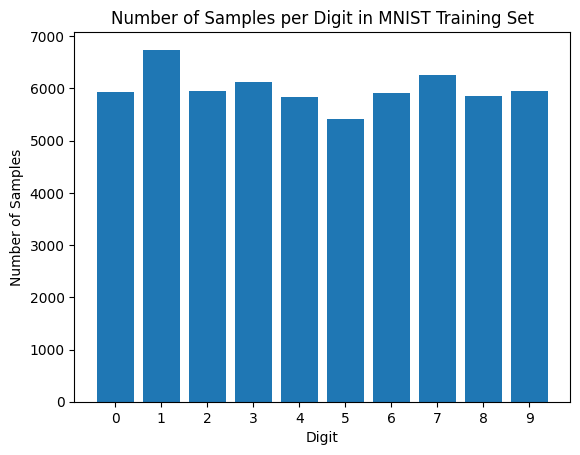

In [18]:
digits, counts = np.unique(y_train, return_counts=True)
plt.bar(digits, counts)
plt.xlabel('Digit')
plt.ylabel('Number of Samples')
plt.title('Number of Samples per Digit in MNIST Training Set')
plt.xticks(digits)
plt.show()

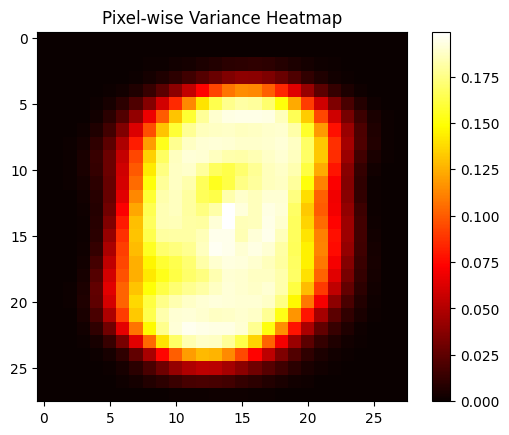

In [19]:
variance = np.var(x_train, axis=0).squeeze()
plt.imshow(variance, cmap='hot')
plt.title('Pixel-wise Variance Heatmap')
plt.colorbar()
plt.show()

## Creating the model

In [22]:
codings_size = 30

generator = keras.models.Sequential([
    keras.layers.Dense(100, activation="relu", input_shape = [codings_size]),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(28 * 28, activation="sigmoid"),
    keras.layers.Reshape([28, 28])
])

discriminator = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28,28]), 
    keras.layers.Dense(150, activation="relu"),
    keras.layers.Dense(100, activation="relu"),
    keras.layers.Dense(1, activation="sigmoid"),
])

gan = keras.models.Sequential([generator, discriminator])


/Users/alessiocarnevale/anaconda3/lib/python3.11/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/alessiocarnevale/anaconda3/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [23]:
discriminator.compile(loss = "binary_crossentropy", optimizer = "rmsprop")
discriminator.trainable = False
gan.compile(loss = "binary_crossentropy", optimizer = "rmsprop")